# Confusion Matrices — From Scratch vs Pretrained

Run one seed × 5-fold CV for both CNN conditions and compute per-fold confusion matrices. Shows which species pairs are hardest to separate.

In [1]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..').resolve()))
import chroma_dcnn; sys.modules.setdefault('msformer', chroma_dcnn)
import chroma_dcnn.models, chroma_dcnn.training
from chroma_dcnn.models.chroma_cnn import ChromatogramCNN, ChromaCNNConfig

DATA_DIR  = Path('../data/fish_oil')
CKPT_PATH = Path('../checkpoints/chroma_pretrain/best.pt')

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')

SPECIES = ['SNA', 'GUR', 'TAR', 'BCO']
COLOURS = {0: '#2196f3', 1: '#ff9800', 2: '#4caf50', 3: '#e91e63'}

y         = np.load(DATA_DIR / 'y.npy')
npz_paths = sorted((DATA_DIR / 'chroma').glob('*.npz'))
chromas   = np.stack([np.load(p)['chroma'] for p in npz_paths])
print(f'Dataset: {chromas.shape}')

Using device: mps
Dataset: (103, 200, 1000)


In [2]:
def train_and_predict(chromas, y, condition, ckpt_path=None, seed=0, epochs=200):
    """Run 5-fold CV for one condition; return concatenated (true, pred) arrays."""
    torch.manual_seed(seed); np.random.seed(seed)
    cfg = ChromaCNNConfig(mz_max=1000, cnn_channels=128, kernel_size=7,
                          num_classes=4, dropout=0.3)
    # pretrained model uses lr=5e-5 and needs more patience to converge
    patience = 15 if condition == 'chroma_pretrain' else 10
    all_true, all_pred = [], []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    for fold, (tr, te) in enumerate(skf.split(chromas, y)):
        X_tr = torch.tensor(chromas[tr], dtype=torch.float32).to(DEVICE)
        y_tr = torch.tensor(y[tr],       dtype=torch.long).to(DEVICE)
        X_te = torch.tensor(chromas[te], dtype=torch.float32).to(DEVICE)

        model = ChromatogramCNN(cfg).to(DEVICE)
        if condition == 'chroma_pretrain' and ckpt_path:
            model.load_pretrained_chroma_encoder(str(ckpt_path))

        lr   = 1e-3 if condition == 'from_scratch' else 5e-5
        opt  = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        sch  = CosineAnnealingLR(opt, T_max=epochs)
        crit = nn.CrossEntropyLoss()
        loader = DataLoader(
            torch.utils.data.TensorDataset(X_tr, y_tr),
            batch_size=16, shuffle=True)

        best_loss, best_state, stale = 1e9, None, 0
        model.train()
        for ep in range(epochs):
            for xb, yb in loader:
                opt.zero_grad()
                crit(model(xb), yb).backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            sch.step()
            with torch.no_grad():
                vl = crit(model(X_tr), y_tr).item()
            if vl < best_loss:
                best_loss, best_state, stale = vl, copy.deepcopy(model.state_dict()), 0
            else:
                stale += 1
                if stale >= patience: break

        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            preds = model(X_te).argmax(dim=1).cpu().numpy()
        all_true.extend(y[te])
        all_pred.extend(preds)
        print(f'  Fold {fold+1}: BA={balanced_accuracy_score(y[te], preds):.3f}', end='  ')
    print()
    return np.array(all_true), np.array(all_pred)

print('Training from_scratch (1 seed × 5 folds) …')
true_s, pred_s = train_and_predict(chromas, y, 'from_scratch', seed=0)
print(f'Overall BA: {balanced_accuracy_score(true_s, pred_s):.3f}')

Training from_scratch (1 seed × 5 folds) …


  Fold 1: BA=0.708  

  Fold 2: BA=0.729  

  Fold 3: BA=0.729  

  Fold 4: BA=0.894  

  Fold 5: BA=0.854  
Overall BA: 0.772


In [3]:
print('Training chroma_pretrain (1 seed × 5 folds) …')
true_p, pred_p = train_and_predict(chromas, y, 'chroma_pretrain', ckpt_path=CKPT_PATH, seed=0)
print(f'Overall BA: {balanced_accuracy_score(true_p, pred_p):.3f}')

Training chroma_pretrain (1 seed × 5 folds) …
  Loaded pretrained spec_proj from ../checkpoints/chroma_pretrain/best.pt
  Loaded pretrained CNN from ../checkpoints/chroma_pretrain/best.pt


  Fold 1: BA=0.769    Loaded pretrained spec_proj from ../checkpoints/chroma_pretrain/best.pt
  Loaded pretrained CNN from ../checkpoints/chroma_pretrain/best.pt


  Fold 2: BA=0.833    Loaded pretrained spec_proj from ../checkpoints/chroma_pretrain/best.pt
  Loaded pretrained CNN from ../checkpoints/chroma_pretrain/best.pt


  Fold 3: BA=0.750    Loaded pretrained spec_proj from ../checkpoints/chroma_pretrain/best.pt
  Loaded pretrained CNN from ../checkpoints/chroma_pretrain/best.pt


  Fold 4: BA=0.894    Loaded pretrained spec_proj from ../checkpoints/chroma_pretrain/best.pt
  Loaded pretrained CNN from ../checkpoints/chroma_pretrain/best.pt


  Fold 5: BA=0.875  
Overall BA: 0.814


## Confusion matrices — side by side

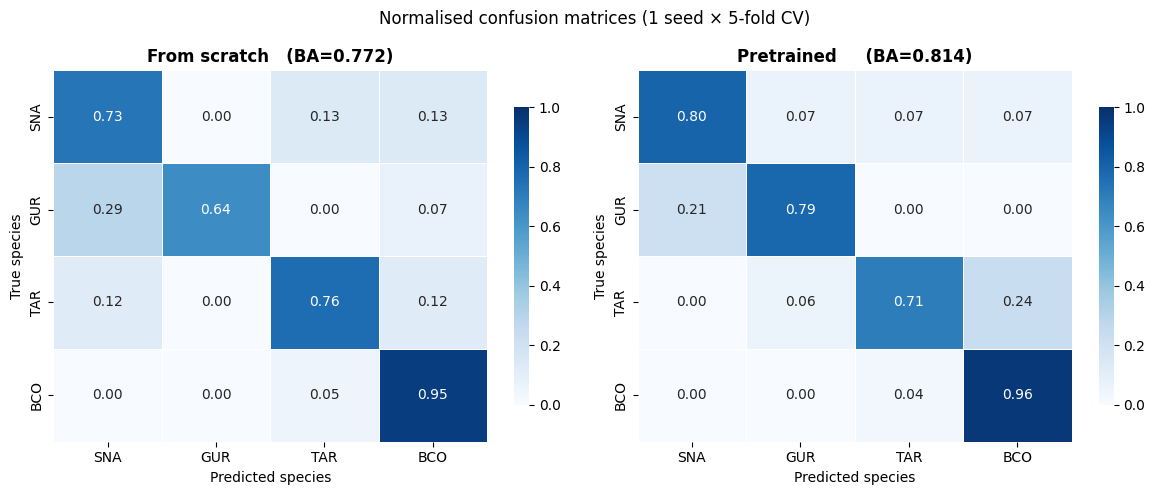

In [4]:
cm_s = confusion_matrix(true_s, pred_s, normalize='true')
cm_p = confusion_matrix(true_p, pred_p, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(
        axes,
        [cm_s, cm_p],
        [f'From scratch   (BA={balanced_accuracy_score(true_s,pred_s):.3f})',
         f'Pretrained     (BA={balanced_accuracy_score(true_p,pred_p):.3f})']):

    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=SPECIES, yticklabels=SPECIES,
                linewidths=0.5, vmin=0, vmax=1, ax=ax,
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted species')
    ax.set_ylabel('True species')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Normalised confusion matrices (1 seed × 5-fold CV)', fontsize=12)
plt.tight_layout()
plt.show()

## Per-class recall improvement

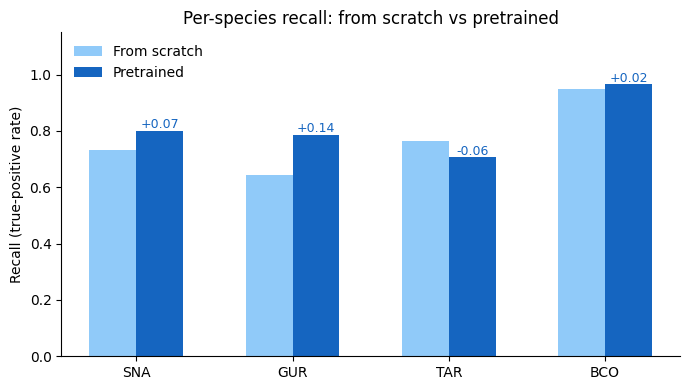

In [5]:
recall_s = cm_s.diagonal()
recall_p = cm_p.diagonal()
lift     = recall_p - recall_s

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(4)
w = 0.3
ax.bar(x - w/2, recall_s, w, label='From scratch', color='#90caf9')
ax.bar(x + w/2, recall_p, w, label='Pretrained',   color='#1565c0')
for i, (rs, rp) in enumerate(zip(recall_s, recall_p)):
    ax.annotate(f'{rp-rs:+.2f}', xy=(x[i]+w/2, rp+0.01),
                ha='center', fontsize=9, color='#1565c0')
ax.set_xticks(x)
ax.set_xticklabels(SPECIES)
ax.set_ylabel('Recall (true-positive rate)')
ax.set_ylim(0, 1.15)
ax.set_title('Per-species recall: from scratch vs pretrained')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()